# 01 — Exploring the triage datasets

Step 1 of `docs/AI-PLAN.md`: look at the data **before** modelling — class balance, text lengths, duplicates.

Run `python -m src.download_data` first so `data/raw/` exists.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from src.paths import DSP_SEVERITY_CSV, SPECIALTY_MAP
from src.prepare import load_dsp, load_s2d

s2d = load_s2d()
dsp = load_dsp()
print('Symptom2Disease rows:', len(s2d))
print('Disease Symptom Prediction rows:', len(dsp))

Symptom2Disease rows: 1200
Disease Symptom Prediction rows: 4920


## Symptom2Disease — patients' own words

In [2]:
pd.set_option('display.max_colwidth', 160)
s2d.sample(5, random_state=1)[['disease', 'text']]

,disease,text
636,bronchial asthma,"I've been dealing with a bad cough, breathing issues, and drowsiness. I've been coughing up a lot of thick, mucoid sputum and have a high fever. All of this..."
683,hypertension,"I woke up this morning with a headache and chest pain, and as the day has gone on, I've also been feeling dizzy and unsteady on my feet"
1033,gastroesophageal reflux disease,"Even when I don't have anything acidic in my stomach, I constantly have a sour taste in my mouth. I frequently have a lump in my throat and the hiccups."
190,chicken pox,I have swollen red lymph nodes on my arms and legs that itch when I touch them. I'm also suffering from a terrible headache and a mild fever. I don't feel l...
1083,drug reaction,"Along with a change in taste and smell, my tongue also has a metallic aftertaste. occasionally get severe joint and muscular pain"


diseases: 24 | rows per disease: min 50 max 50


count    1200.0
mean       30.7
std         6.7
min        12.0
25%        26.0
50%        30.0
75%        35.0
max        55.0
Name: text, dtype: float64

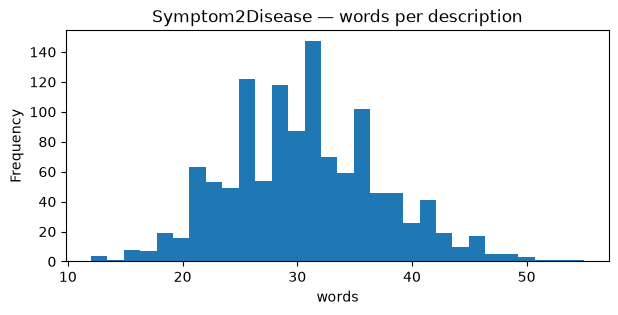

In [3]:
counts = s2d['disease'].value_counts()
print('diseases:', len(counts), '| rows per disease: min', counts.min(), 'max', counts.max())

words = s2d['text'].str.split().str.len()
ax = words.plot.hist(bins=30, figsize=(7, 3), title='Symptom2Disease — words per description')
ax.set_xlabel('words')
words.describe().round(1)

Perfectly balanced at the **disease** level (50 rows each) and reasonably long descriptions — good material for TF-IDF.

## Disease Symptom Prediction — symptom checklists

In [4]:
dsp.sample(5, random_state=1)[['disease', 'text']]

,disease,text
2025,urinary tract infection,"burning micturition, bladder discomfort, foul smell of urine"
1724,gastroenteritis,"vomiting, sunken eyes, diarrhoea"
4500,hypothyroidism,"fatigue, weight gain, cold hands and feets, mood swings, lethargy, dizziness, puffy face and eyes, enlarged thyroid, brittle nails, swollen extremeties, dep..."
2213,chicken pox,"itching, skin rash, lethargy, high fever, headache, loss of appetite, mild fever, swelled lymph nodes, malaise, red spots over body"
4604,cervical spondylosis,"back pain, weakness in limbs, neck pain, dizziness, loss of balance"


In [5]:
unique = dsp.drop_duplicates('text')
print(f'rows: {len(dsp)}  →  distinct checklists: {len(unique)}')
print(f'each distinct checklist is repeated {len(dsp) / len(unique):.1f}x on average')

per_disease = unique['disease'].value_counts()
print('distinct checklists per disease: min', per_disease.min(), 'max', per_disease.max())

rows: 4920  →  distinct checklists: 304
each distinct checklist is repeated 16.2x on average
distinct checklists per disease: min 5 max 10


**The important finding.** The dataset looks large, but it is a few hundred distinct checklists copied many times. A random train/test split would put copies of every test row in the training set and report ~100% accuracy — a number that means nothing. `src/prepare.py` therefore removes duplicates **before** splitting.

## After mapping diseases → specialties

source,dsp,s2d,total
specialty,,,
infectious disease,42,193,235
gastroenterology,88,136,224
dermatology,23,196,219
pulmonology,25,96,121
allergy and immunology,11,100,111
endocrinology,35,50,85
neurology,22,47,69
orthopedics,13,49,62
cardiology,11,50,61


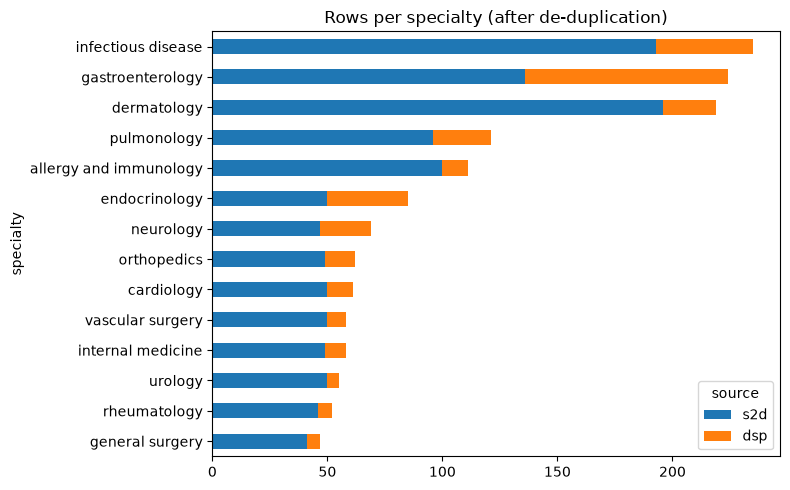

In [6]:
mapping = pd.read_csv(SPECIALTY_MAP).set_index('disease')
both = pd.concat([s2d, dsp]).drop_duplicates('text')
both['specialty'] = both['disease'].map(mapping['specialty'])
both['acuity'] = both['disease'].map(mapping['acuity'])

table = both.groupby(['specialty', 'source']).size().unstack(fill_value=0)
table['total'] = table.sum(axis=1)
table = table.sort_values('total')
table[['s2d', 'dsp']].plot.barh(stacked=True, figsize=(8, 5), title='Rows per specialty (after de-duplication)')
plt.tight_layout()
table.sort_values('total', ascending=False)

The **specialty** classes are imbalanced (many skin and digestive diseases, a single vascular one), which is why the model is trained with `class_weight='balanced'` and judged on **macro-F1**, not accuracy alone.

In [7]:
both['acuity'].value_counts().reindex(['LOW', 'MODERATE', 'HIGH', 'CRITICAL'])

acuity
LOW         389
MODERATE    662
HIGH        396
CRITICAL     10
Name: count, dtype: int64

## Symptom severity weights (input to the risk model)

,Symptom,weight
113,coma,7
46,swelling_of_stomach,7
56,chest_pain,7
57,weakness_in_limbs,7
25,high_fever,7
119,prominent_veins_on_calf,6
101,abnormal_menstruation,6
114,stomach_bleeding,6
102,dischromic_patches,6
84,spinning_movements,6


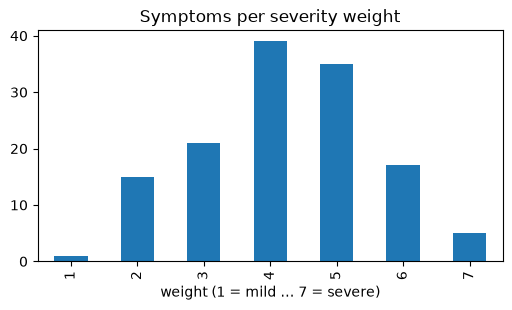

In [8]:
severity = pd.read_csv(DSP_SEVERITY_CSV)
ax = severity['weight'].value_counts().sort_index().plot.bar(figsize=(6, 3), title='Symptoms per severity weight')
ax.set_xlabel('weight (1 = mild … 7 = severe)')
severity.sort_values('weight', ascending=False).head(10)